In [9]:
# Import packages
import os
import sys
import mlflow
sys.path.append(r"C:\Users\Admin\WORK\Project_CV\Model_NLP_sentiment\src")
from dataset import trainset, testset, word2int
import torch
from torch import nn 
from torch import optim
from torch.utils.data import DataLoader
from tqdm import tqdm    
from LSTM_model import RNN
from matplotlib import pyplot as plt

In [2]:
# create dataloaders
trainloader = DataLoader(trainset, shuffle=True, batch_size=20)
testloader = DataLoader(testset, shuffle=True, batch_size=20)

In [4]:
print(f"Dataset size: {len(trainset)}")
print(f"Number of batches: {len(trainloader)}")
print(f"Batch size: {trainloader.batch_size}")

# Size of one batch
sample_batch = next(iter(trainloader))
if isinstance(sample_batch, (list, tuple)):
    print(f"Sample batch token shape: {sample_batch[0].shape}")
    print(f"Sample batch labels shape: {sample_batch[1].shape}")
    
gg,kk =sample_batch
print(gg[2],kk[2])

Dataset size: 1280
Number of batches: 64
Batch size: 20
Sample batch token shape: torch.Size([20, 200])
Sample batch labels shape: torch.Size([20])
tensor([  572,   787,  4469,   432,     3,     2,   122,   693,   290,  1278,
         5845,  1182,  3546,  3145,  5058,  5846,  6950,  6951, 12354,   138,
        12355,  5058,  5845,  1894,  1067,     9,  1078,  8672,    40,  6950,
           94,  5402,  3546,  5847,  1315,   168,    22,  2294,    82, 12356,
         5845,    77,  2904,   532,   569,  2862, 12357,   265,   764,  1339,
         2021,  5417,    77,    21, 12358,  3145,  1943,  1403,  5798,    57,
         6952,    55,  5402,   391,    28,   858,    40,  2344,   268,  3230,
           99,    81,     2,    18,   161,  3817,  8673,  3822,  2890,  8674,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,  

In [5]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

#set hyperparameter
EPOCH = 10
LR = 0.001
vocab_size = len(word2int)
print (vocab_size)
output_size = 1
embed_dim = 227
hidden_size=100
n_layers=1
dropout= False

recom_embed_dim = min(600, round(1.6 * vocab_size**0.5))  #recomendation for choice of embed_dim
print(recom_embed_dim)




cpu
20138
227


In [6]:
class RNN(nn.Module):
    def __init__(self, vocab_size, output_size, embed_dim, hidden_size,  n_layers):
        super(RNN, self).__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim)                      # embedding layer is useful to map input into vector representation
        
        self.lstm = nn.LSTM(embed_dim, hidden_size, n_layers, batch_first=True)    # LSTM layer preserved by PyTorch library
                                                                                                    # batch_first=True - input data format (batch, sequence, features)
        
        # self.dropout = nn.Dropout(0.3)                                              # dropout layer     

        self.fc1 = nn.Linear(hidden_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)             # Linear layer for output
        self.sigmoid = nn.Sigmoid()                                # Sigmoid layer cz we will have binary classification


    def forward(self, x):
        x = x.long()                          # changes to type (int64) for embedding ((batch, seq_len))
        # print(x.shape)                        
        out = self.embedding(x)               # (batch, seq_len) -> (batch, seq_len, embed_dim)
        # print('Emb:', out.shape)             
        out, _ =  self.lstm(out)             # # (batch, seq_len, embed_dim) -> (batch, seq_len, hidden_size)    out,_ = all_outputs, (final_hidden, final_cell) 
        # print('LSTM:', out.shape)
        out = out[:, -1, :]                 # берет только последний выход последовательности
        # print('-1:', out.shape)                                    # Использует только последний выход LSTM - подходит для задач, где важен общий контекст
        out = self.fc1(out)
        # print('FC1:', out.shape)
        out = self.relu(out)
        # print('Relu:', out.shape)
        # apply dropout and fully connected layer
        # out = self.dropout(o)
        out = self.fc2(out)
        # print('FC2:', out.shape)
        out = self.sigmoid(out)
        # print('Sigmoid:', out.shape)

        return out

In [7]:
#define ResNet18
net = RNN(vocab_size, output_size, embed_dim, hidden_size,  n_layers).to(device)

#define loss funtion & optimizer
loss_func = nn.BCELoss()
optimizer = optim.Adam(net.parameters(), lr=LR)                      # momentum=0.9, weight_decay=5e-4

In [8]:
# Training cycle
train_losses = []  # for plots
test_losses = []
train_accuracies = []  # Добавим для отслеживания точности
test_accuracies = []

for epoch in range(EPOCH):
    print(f'\nEpoch: {epoch + 1}/{EPOCH}')
    
    # Training phase
    net.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0
    max_train_acc = 0
    max_test_acc = 0
    min_test_loss =0
    
    for i, data in enumerate(trainloader, 0):
        # Подготовка данных
        inputs, labels = data
        labels = labels.unsqueeze(1)  
        inputs, labels = inputs.to(device), labels.to(device).float() 
        optimizer.zero_grad()
        
        # Forward pass
        outputs = net(inputs)

        # print(outputs.shape)
        # print(labels.shape)
        # break
        loss = loss_func(outputs, labels)
        loss.backward()
        optimizer.step()
        
        # Расчет точности
        predicted = (outputs >= 0.5).float()               #  .float() - преобразует True в 1.0, False в 0.0
        train_correct += (predicted == labels).float().sum().item()
        train_total += labels.size(0)
        
        # Накопление потерь
        train_loss += loss.item() * labels.size(0)                                     # train_loss+= mean_batch_loss * batch_size 
        
        acc_train = 100.0 * train_correct / train_total     
        if acc_train > max_train_acc:
            max_train_acc = acc_train
            min_train_loss = train_loss / train_total
                              
        # print('[epoch:%d, iter:%d] Loss: %.03f | Acc: %.2f%% ' 
        #       % (epoch + 1, (i + 1 ), train_loss / train_total, acc_train))

       
        # Периодический вывод прогресса
        if (i + 1) % 100 == 0 or (i + 1) == len(trainloader):
            print(f'TRAIN: Batch: {i+1}/{len(trainloader)} | Loss: {min_train_loss:.4f} | Acc: {max_train_acc:.2f}%')

    # Расчет средних значений за эпоху
    epoch_train_loss = train_loss / train_total
    epoch_train_acc = 100.0 * train_correct / train_total
    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_acc)
    
    # Validation phase
    net.eval()
    test_loss = 0.0
    test_correct = 0
    test_total = 0
    
    with torch.no_grad():
        for i, data in enumerate(testloader, 0):
            inputs, labels = data
            labels = labels.unsqueeze(1)
            inputs, labels = inputs.to(device), labels.to(device).float()
            
            outputs = net(inputs)
            loss = loss_func(outputs, labels)
            
            predicted = (outputs >= 0.5).float()
            test_correct += (predicted == labels).float().sum().item()
            test_total += labels.size(0)
            test_loss += loss.item() * labels.size(0)
    
            acc_test = 100.0 * test_correct / test_total

            if acc_test > max_test_acc:
                max_test_acc = acc_test
                min_test_loss = test_loss / test_total
                torch.save(net, f'model_my_nlp.pth')                 # saves the model with the best performance

            if (i + 1) % 100 == 0 or (i + 1) == len(testloader):
                print(f'TEST Batch: {i+1}/{len(testloader)} | Loss: {min_test_loss:.4f} | Acc: {max_test_acc:.2f}%')

    epoch_test_loss = test_loss / test_total
    epoch_test_acc = 100.0 * test_correct / test_total
            
    test_losses.append(epoch_test_loss)
    test_accuracies.append(epoch_test_acc)
    
    # Вывод результатов эпохи
    print(f'Epoch {epoch+1} Summary:')
    print(f'Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.2f}%')
    print(f'Test Loss: {epoch_test_loss:.4f} | Test Acc: {epoch_test_acc:.2f}%')
    print('------------')
    print('MAX_train_acc: %.2f%% ' % (max_train_acc))      
    print('MAX_test_acc: %.2f%% ' % (max_test_acc))
    print('MIN_train_loss: %.3f ' % (min_train_loss))      
    print('MIN_test_loss: %.3f ' % (min_test_loss))   
    
    
    # if epoch_test_acc > max_test_acc:
    #     max_test_acc = epoch_test_acc
    #     torch.save(net.state_dict(), 'best_model.pth')
    #     print('Best model saved!')


Epoch: 1/10
TRAIN: Batch: 64/64 | Loss: 0.6948 | Acc: 50.26%
TEST Batch: 16/16 | Loss: 0.6858 | Acc: 56.67%
Epoch 1 Summary:
Train Loss: 0.6954 | Train Acc: 50.00%
Test Loss: 0.6938 | Test Acc: 52.19%
------------
MAX_train_acc: 50.26% 
MAX_test_acc: 56.67% 
MIN_train_loss: 0.695 
MIN_test_loss: 0.686 

Epoch: 2/10
TRAIN: Batch: 64/64 | Loss: 0.6895 | Acc: 58.00%
TEST Batch: 16/16 | Loss: 0.6764 | Acc: 55.00%
Epoch 2 Summary:
Train Loss: 0.6842 | Train Acc: 54.84%
Test Loss: 0.6922 | Test Acc: 52.19%
------------
MAX_train_acc: 58.00% 
MAX_test_acc: 55.00% 
MIN_train_loss: 0.689 
MIN_test_loss: 0.676 

Epoch: 3/10
TRAIN: Batch: 64/64 | Loss: 0.6560 | Acc: 70.00%
TEST Batch: 16/16 | Loss: 0.6254 | Acc: 55.00%
Epoch 3 Summary:
Train Loss: 0.6366 | Train Acc: 56.41%
Test Loss: 0.7094 | Test Acc: 51.25%
------------
MAX_train_acc: 70.00% 
MAX_test_acc: 55.00% 
MIN_train_loss: 0.656 
MIN_test_loss: 0.625 

Epoch: 4/10
TRAIN: Batch: 64/64 | Loss: 0.6881 | Acc: 60.00%
TEST Batch: 16/16 | Los

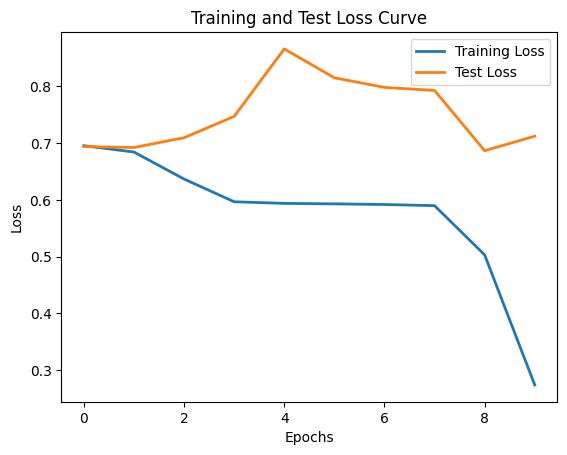

In [10]:
plt.plot(train_losses, label="Training Loss",linewidth=2)
plt.plot(test_losses, label="Test Loss",linewidth=2)
plt.title('Training and Test Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()